# Deadline Predictor V7 - Simplified & Robust (Fixed Viz)


In [251]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

warnings.filterwarnings('ignore')


In [252]:
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_PATH = os.path.join(MODEL_DIR, 'deadline_model_v7_simple.joblib')

PROJECTS = {
    'Aurora': {
        'issues':  r'PM_Kaggle_dataset\AgileScrumSprintVelocityDataSet\Agile Scrum Dataset\Finalized Datasets for Aurora Project\Aurora Issues 554.csv',
        'sprints': r'PM_Kaggle_dataset\AgileScrumSprintVelocityDataSet\Agile Scrum Dataset\Finalized Datasets for Aurora Project\Aurora Sprints 41.csv',
    }
}


In [253]:
# -----------------------------
# FEATURE ENGINEERING & STRICT CLEANING
# -----------------------------
def _lower_cols(df):
    df.columns = [c.strip().replace(' ', '_').lower() for c in df.columns]
    return df

def load_and_aggregate():
    combined = []
    for pname, p in PROJECTS.items():
        # Load
        iss = _lower_cols(pd.read_csv(p['issues'], on_bad_lines='skip', engine='python'))
        spr = _lower_cols(pd.read_csv(p['sprints'], on_bad_lines='skip', engine='python'))
        
        iss.rename(columns={'priority': 'priorityid', 'storypoints': 'storypoint'}, inplace=True)
        
        # --- CALCULATE DURATION ---
        if 'sprintstartdate' in spr.columns and 'sprintcompletedate' in spr.columns:
             spr['start'] = pd.to_datetime(spr['sprintstartdate'], format='%d-%m-%Y %H:%M', errors='coerce')
             spr['end']   = pd.to_datetime(spr['sprintcompletedate'], format='%d-%m-%Y %H:%M', errors='coerce')
             spr['actual_duration'] = (spr['end'] - spr['start']).dt.days
             if 'sprintlength' in spr.columns:
                 spr['actual_duration'] = spr['actual_duration'].fillna(spr['sprintlength'])
        elif 'sprintlength' in spr.columns:
             spr['actual_duration'] = spr['sprintlength']

        # Filter Valid Sprints
        valid_sprints = spr['sprintid'].unique()
        iss = iss[iss['sprint'].isin(valid_sprints)]
        
        # Aggregations
        agg = iss.groupby('sprint').agg({
            'storypoint': 'sum',
            'priorityid': 'mean',
            'key': 'count'
        }).reset_index()
        
        # Join
        full = agg.merge(spr[['sprintid', 'actual_duration']], left_on='sprint', right_on='sprintid')
        
        # Density Features
        full['points_per_issue'] = full['storypoint'] / full['key']
        full['complexity'] = full['storypoint'] * (4 - full['priorityid'].fillna(2))
        
        combined.append(full)
        
    return pd.concat(combined, ignore_index=True)

df = load_and_aggregate()
df = df.dropna(subset=['actual_duration'])

print(f'Raw Rows: {len(df)}')

# --- STRICT FILTERING ---
# A Sprint must be at least 1 week (7 days) and at most 5 weeks (35 days)
# Removing 1-day tests and 100-day anomalies
df = df[(df['actual_duration'] >= 7) & (df['actual_duration'] <= 35)]
print(f'Clean Rows (7-35 days): {len(df)}')


Raw Rows: 40
Clean Rows (7-35 days): 38


In [254]:
# -----------------------------
# ROBUST MODELING (Grid Search Tuning)
# -----------------------------
from sklearn.model_selection import GridSearchCV

X = df[['storypoint', 'points_per_issue', 'complexity']]
y = df['actual_duration']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the Parameter Grid
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 2, 3],
    'max_features': ['sqrt', 'log2', None]
}

# Setup Grid Search
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                          # 5-Fold Cross Validation
    scoring='neg_mean_absolute_error', # Optimize for MAE
    n_jobs=-1,                     # Use all CPU cores
    verbose=1
)

print('Starting Hyperparameter Tuning...')
grid_search.fit(X_train, y_train)

# Get Best Model
model = grid_search.best_estimator_

print(f'\nBest Params: {grid_search.best_params_}')
print(f'Best CV Score (MAE): {-grid_search.best_score_:.2f} Days')

Starting Hyperparameter Tuning...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Params: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV Score (MAE): 2.38 Days



MODEL PERFORMANCE REPORT
-------------------------
   Mean Absolute Error (MAE): 0.92 Days (Avg miss)
   Root Mean Sq Error (RMSE): 1.17 Days (Penalizes big misses)
   Mean Abs % Error   (MAPE): 6.84% (Relative error)
   R² Score                 : 0.4354


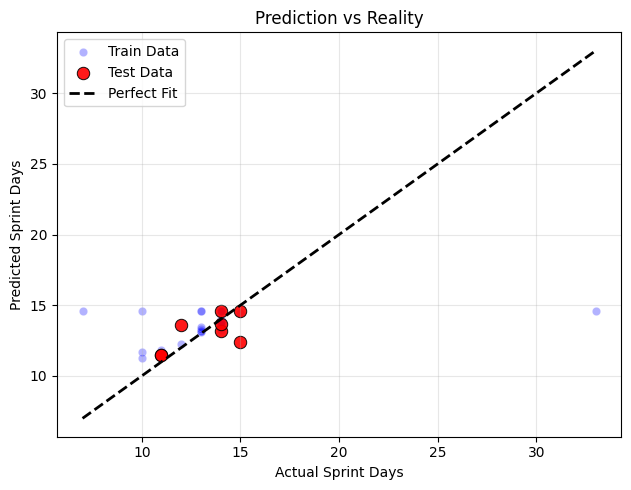

['models\\deadline_model_v7_simple.joblib']

In [255]:
# -----------------------------
# COMPREHENSIVE EVALUATION
# -----------------------------
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import scipy.stats as stats

y_pred = model.predict(X_test)
train_pred = model.predict(X_train)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'\nMODEL PERFORMANCE REPORT')
print(f'-------------------------')
print(f'   Mean Absolute Error (MAE): {mae:.2f} Days (Avg miss)')
print(f'   Root Mean Sq Error (RMSE): {rmse:.2f} Days (Penalizes big misses)')
print(f'   Mean Abs % Error   (MAPE): {mape:.2%} (Relative error)')
print(f'   R² Score                 : {r2:.4f}')

# Visualization Dashboard
plt.figure(figsize=(18, 5))

# Plot 1: Prediction vs Reality
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_train, y=train_pred, color='blue', alpha=0.3, label='Train Data')
sns.scatterplot(x=y_test, y=y_pred, color='red', alpha=0.9, s=80, edgecolor='black', label='Test Data')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Sprint Days')
plt.ylabel('Predicted Sprint Days')
plt.title('Prediction vs Reality')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

joblib.dump(model, MODEL_PATH)

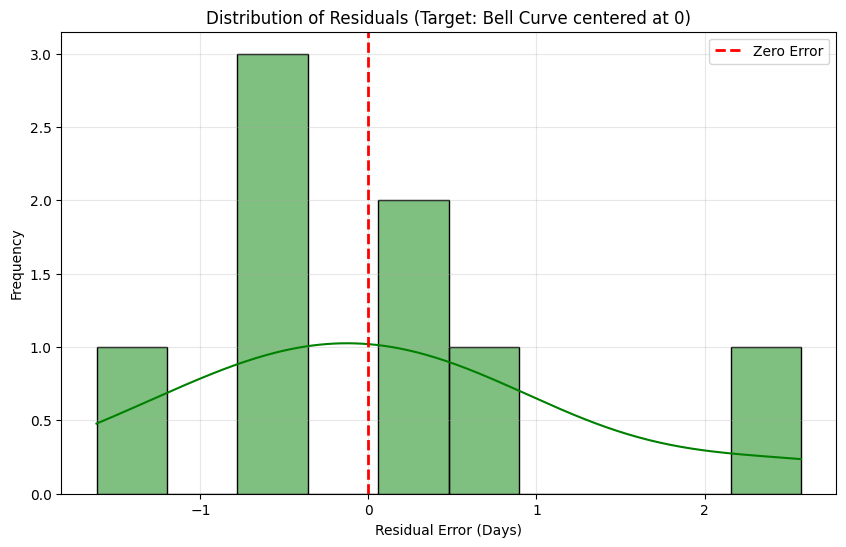

In [256]:
# Residual Distribution Graph
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='green', bins=10)

plt.xlabel('Residual Error (Days)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals (Target: Bell Curve centered at 0)')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')  # Zero center line
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()